In [1]:
import os
import pandas as pd
import numpy as np 
import json
import matplotlib.pyplot as plt
from pathlib import Path

### 1. Load Sensitivity Files

In [2]:
ray_base = '/data/user/fkrafft/csky_gfu_tests'
king_base = '/data/user/fkrafft/csky_king_tests'

In [3]:
rayleigh_paths = {
    2.0 : os.path.join(ray_base, 'rayleigh_benchmark_gamma_2.0'),
    2.5 : os.path.join(ray_base, 'rayleigh_benchmark_gamma_2.5'),
    2.7 : os.path.join(ray_base, 'rayleigh_benchmark_gamma_2.7'),
    3.0 : os.path.join(ray_base, 'rayleigh_benchmark_gamma_3.0'),
}
king_paths = {
    2.0 : os.path.join(king_base, 'min_count_150_angErr12_gamma_2.0'),
    2.5 : os.path.join(king_base, 'min_count_150_angErr12_gamma_2.5'),
    2.7 : os.path.join(king_base, 'min_count_150_angErr12_gamma_2.7'),
    3.0 : os.path.join(king_base, 'min_count_150_angErr12_gamma_3.0'),
}

In [4]:
rayleigh_3sig_disc = {}
king_3sig_disc = {}

rayleigh_sens = {}
king_sens = {}

In [5]:
for gamma, path in rayleigh_paths.items():
    input_dir = Path(path)
    rayleigh_3sig_disc[gamma] = {}
    for file in input_dir.glob("rayleigh_3sig_disc*.json"):
        
        with open(file) as f:
            disc_3sig_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        rayleigh_3sig_disc[gamma][sin_dec] = disc_3sig_data

In [6]:
for gamma, path in rayleigh_paths.items():
    input_dir = Path(path)
    rayleigh_sens[gamma] = {}
    for file in input_dir.glob("rayleigh_sens*.json"):
        
        with open(file) as f:
            disc_3sig_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        rayleigh_sens[gamma][sin_dec] = disc_3sig_data

In [7]:
for gamma, path in king_paths.items():
    input_dir = Path(path)
    king_3sig_disc[gamma] = {}
    for file in input_dir.glob("TEST_king_3sig_disc*.json"):

        with open(file) as f:
            disc_3sig_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_3sig_disc[gamma][sin_dec] = disc_3sig_data

In [8]:
for gamma, path in king_paths.items():
    input_dir = Path(path)
    king_sens[gamma] = {}
    for file in input_dir.glob("TEST_king_sens*.json"):

        with open(file) as f:
            disc_3sig_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_sens[gamma][sin_dec] = disc_3sig_data

<>:88: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4192540/768644567.py:88: SyntaxWarning: invalid escape sequence '\s'
  """ ax.set_title(


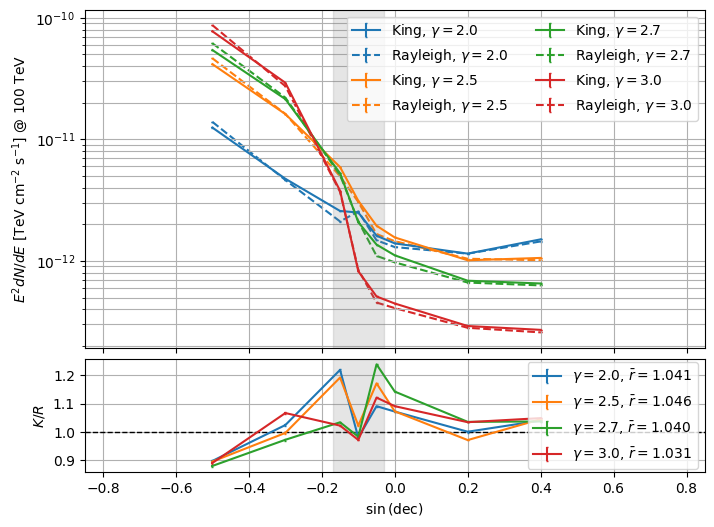

{2.0: 1.0405831420453562,
 2.5: 1.04584500070706,
 2.7: 1.040370570775545,
 3.0: 1.0308065231481267}

In [9]:
fig, (ax, ax_ratio) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

scores = {}

gammas = sorted(set(king_3sig_disc.keys()) & set(rayleigh_3sig_disc.keys()))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, gamma in enumerate(gammas):
    sindecs = sorted(
        set(king_3sig_disc[gamma].keys())
        & set(rayleigh_3sig_disc[gamma].keys())
    )

    if len(sindecs) == 0:
        continue

    x = np.asarray(sindecs)

    king_y = np.asarray([
        king_3sig_disc[gamma][s]["flux"]
        for s in sindecs
    ])
    king_yerr = np.asarray([
        king_3sig_disc[gamma][s]["flux_err"]
        for s in sindecs
    ])

    rayleigh_y = np.asarray([
        rayleigh_3sig_disc[gamma][s]["flux"]
        for s in sindecs
    ])
    rayleigh_yerr = np.asarray([
        rayleigh_3sig_disc[gamma][s]["flux_err"]
        for s in sindecs
    ])

    ratio = king_y / rayleigh_y
    ratio_err = ratio * np.sqrt(
        (king_yerr / king_y) ** 2
        + (rayleigh_yerr / rayleigh_y) ** 2
    )

    scores[gamma] = np.mean(ratio)

    # same color for King and Rayleigh
    color = colors[i % len(colors)]

    ax.errorbar(
        x,
        king_y,
        yerr=king_yerr,
        ls="-",
        marker="",
        capsize=1,
        color=color,
        zorder=3,
        label=rf"King, $\gamma={gamma}$",
    )

    ax.errorbar(
        x,
        rayleigh_y,
        yerr=rayleigh_yerr,
        ls="--",
        marker="",
        capsize=1,
        color=color,
        zorder=1,
        label=rf"Rayleigh, $\gamma={gamma}$",
    )

    ax_ratio.errorbar(
        x,
        ratio,
        yerr=ratio_err,
        ls="-",
        marker="",
        capsize=1,
        color=color,
        zorder=3,
        label=rf"$\gamma={gamma}$, $\bar r={scores[gamma]:.3f}$",
    )

""" ax.set_title(
    r"King vs Rayleigh 3$\sigma$ discovery potential"
) """

ax.set_yscale("log")
ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax.set_xlim(-0.85, 0.85)
ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
ax.grid(which="both", zorder=1)
ax.legend(ncol=2)

ax_ratio.axhline(1, color="black", lw=1, ls="--")
ax_ratio.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax_ratio.set_xlabel(r"$\sin{(\mathrm{dec})}$")
ax_ratio.set_ylabel(r"$K / R$")
ax_ratio.grid(which="both", zorder=1)
ax_ratio.legend(loc = 'right')

plt.show()

scores

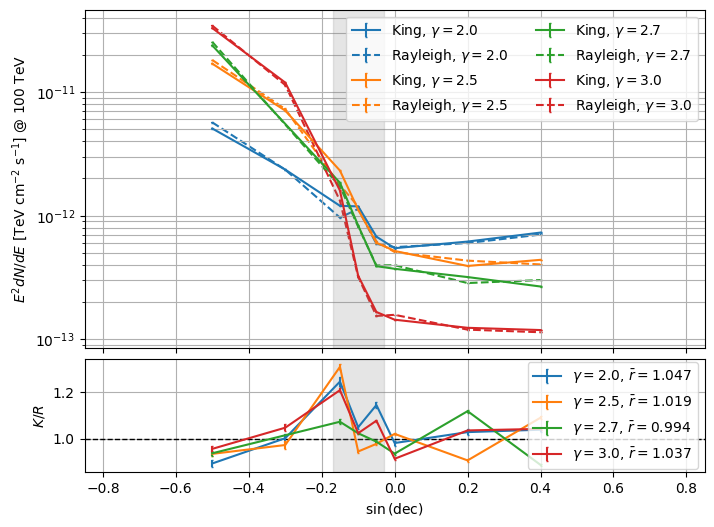

{2.0: 1.0472722924858264,
 2.5: 1.018915210661906,
 2.7: 0.9939075576870333,
 3.0: 1.0374446894218414}

In [10]:


fig, (ax, ax_ratio) = plt.subplots(
    2, 1,
    figsize=(8, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

scores = {}

gammas = sorted(set(king_sens.keys()) & set(rayleigh_sens.keys()))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, gamma in enumerate(gammas):
    sindecs = sorted(
        set(king_sens[gamma].keys())
        & set(rayleigh_sens[gamma].keys())
    )

    if len(sindecs) == 0:
        continue

    x = np.asarray(sindecs)

    king_y = np.asarray(
        [king_sens[gamma][s]["flux"] for s in sindecs],
        dtype=float,
    )
    king_yerr = np.asarray(
        [king_sens[gamma][s]["flux_err"] for s in sindecs],
        dtype=float,
    )

    rayleigh_y = np.asarray(
        [rayleigh_sens[gamma][s]["flux"] for s in sindecs],
        dtype=float,
    )
    rayleigh_yerr = np.asarray(
        [rayleigh_sens[gamma][s]["flux_err"] for s in sindecs],
        dtype=float,
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = king_y / rayleigh_y
        ratio_err = ratio * np.sqrt(
            (king_yerr / king_y) ** 2
            + (rayleigh_yerr / rayleigh_y) ** 2
        )

    valid_flux = (
        np.isfinite(king_y)
        & np.isfinite(rayleigh_y)
        & np.isfinite(king_yerr)
        & np.isfinite(rayleigh_yerr)
        & (king_y > 0)
        & (rayleigh_y > 0)
    )

    valid_ratio = (
        valid_flux
        & np.isfinite(ratio)
        & np.isfinite(ratio_err)
    )

    inf_ratio = (
        valid_flux
        & np.isinf(ratio)
    )

    if not np.any(valid_ratio):
        continue

    scores[gamma] = np.mean(ratio[valid_ratio])

    color = colors[i % len(colors)]

    ax.errorbar(
        x[valid_flux],
        king_y[valid_flux],
        yerr=king_yerr[valid_flux],
        ls="-",
        marker="",
        capsize=1,
        color=color,
        zorder=3,
        label=rf"King, $\gamma={gamma}$",
    )

    ax.errorbar(
        x[valid_flux],
        rayleigh_y[valid_flux],
        yerr=rayleigh_yerr[valid_flux],
        ls="--",
        marker="",
        capsize=1,
        color=color,
        zorder=1,
        label=rf"Rayleigh, $\gamma={gamma}$",
    )

    ax_ratio.errorbar(
        x[valid_ratio],
        ratio[valid_ratio],
        yerr=ratio_err[valid_ratio],
        ls="-",
        marker="",
        capsize=1,
        color=color,
        zorder=3,
        label=rf"$\gamma={gamma}$, $\bar r={scores[gamma]:.3f}$",
    )

    if np.any(inf_ratio):
        top_marker_y = np.nanmax(ratio[valid_ratio]) * 1.1

        ax_ratio.scatter(
            x[inf_ratio],
            np.full(np.sum(inf_ratio), top_marker_y),
            marker="^",
            color=color,
            zorder=4,
            label=rf"$\gamma={gamma}$, $K/R=\infty$",
        )

ax.set_yscale("log")
ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax.set_xlim(-0.85, 0.85)
ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
ax.grid(which="both", zorder=1)
ax.legend(ncol=2)

ax_ratio.axhline(1, color="black", lw=1, ls="--")
ax_ratio.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax_ratio.set_xlabel(r"$\sin{(\mathrm{dec})}$")
ax_ratio.set_ylabel(r"$K / R$")
ax_ratio.grid(which="both", zorder=1)
ax_ratio.legend(loc="right")

plt.show()

scores

In [11]:
print(king_y.dtype)
print(rayleigh_y.dtype)

print(type(king_y[0]), king_y[0])
print(type(rayleigh_y[0]), rayleigh_y[0])

float64
float64
<class 'numpy.float64'> 3.285667579050697e-11
<class 'numpy.float64'> 3.4385655467572445e-11


### only Rayleigh plots:

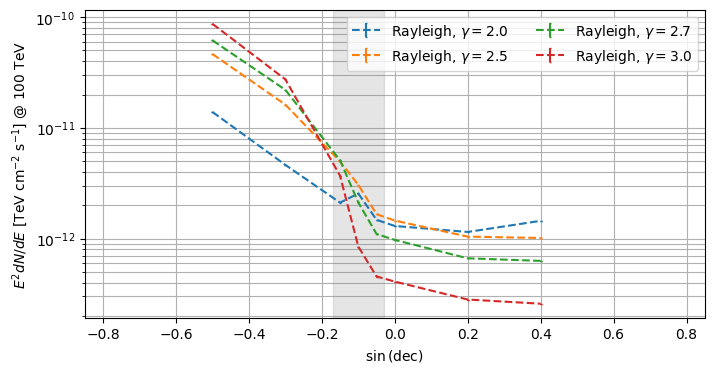

{2.0: 3.575919838146112e-12,
 2.5: 9.485472040980755e-12,
 2.7: 1.180423034316542e-11,
 3.0: 1.5057967820537654e-11}

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))

scores = {}

gammas = sorted(rayleigh_3sig_disc.keys())
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, gamma in enumerate(gammas):
    sindecs = sorted(rayleigh_3sig_disc[gamma].keys())

    if len(sindecs) == 0:
        continue

    x = np.asarray(sindecs, dtype=float)

    rayleigh_y = np.asarray([
        rayleigh_3sig_disc[gamma][s]["flux"]
        for s in sindecs
    ], dtype=float)

    rayleigh_yerr = np.asarray([
        rayleigh_3sig_disc[gamma][s]["flux_err"]
        for s in sindecs
    ], dtype=float)

    scores[gamma] = np.mean(rayleigh_y)

    color = colors[i % len(colors)]

    ax.errorbar(
        x,
        rayleigh_y,
        yerr=rayleigh_yerr,
        ls="--",
        marker="",
        capsize=1,
        color=color,
        zorder=3,
        label=rf"Rayleigh, $\gamma={gamma}$",
    )

ax.set_yscale("log")
ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax.set_xlim(-0.85, 0.85)

ax.set_xlabel(r"$\sin{(\mathrm{dec})}$")
ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
ax.grid(which="both", zorder=1)
ax.legend(ncol=2)

plt.show()

scores

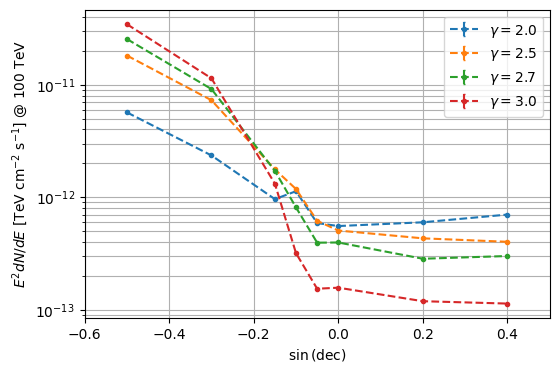

{2.0: 1.571148109043992e-12,
 2.5: 3.789241734666671e-12,
 2.7: 4.805982364876339e-12,
 3.0: 5.99357479495025e-12}

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))

scores = {}

gammas = sorted(rayleigh_sens.keys())
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, gamma in enumerate(gammas):
    sindecs = sorted(rayleigh_sens[gamma].keys())

    if len(sindecs) == 0:
        continue

    x = np.asarray(sindecs, dtype=float)

    rayleigh_y = np.asarray(
        [rayleigh_sens[gamma][s]["flux"] for s in sindecs],
        dtype=float,
    )
    rayleigh_yerr = np.asarray(
        [rayleigh_sens[gamma][s]["flux_err"] for s in sindecs],
        dtype=float,
    )

    valid = (
        np.isfinite(rayleigh_y)
        & np.isfinite(rayleigh_yerr)
        & (rayleigh_y > 0)
    )

    if not np.any(valid):
        continue

    scores[gamma] = np.mean(rayleigh_y[valid])

    color = colors[i % len(colors)]

    ax.errorbar(
        x[valid],
        rayleigh_y[valid],
        yerr=rayleigh_yerr[valid],
        ls="--",
        marker=".",
        capsize=1,
        color=color,
        zorder=3,
        label=rf"$\gamma={gamma}$",
    )

ax.set_yscale("log")
#ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax.set_xlim(-0.6, 0.5)

ax.set_xlabel(r"$\sin{(\mathrm{dec})}$")
ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
ax.grid(which="both", zorder=1)
ax.legend()

plt.show()

scores